##### `Stape 1 : Prepare The Data`

In [37]:
"""IMPORT EVERYTHING.. """
# Data manipulation
import pandas as pd
import numpy as np

# # Quantitative analysis / indicators
import talib
# import backtrader as bt
# import vectorbt as vbt


# # Machine learning / statistics
# import scipy
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression

# # Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf


from resampler import OHLCVResampler
# # Jupyter Notebook magic for inline plots
# %matplotlib inline

import pandas_ta as ta



In [38]:
"""Load Source OHLCV dta"""

df = pd.read_parquet("../Src/XAUUSDc_M1.parquet", engine="pyarrow")

In [39]:
"""Setting Chart Configs"""
from ChartterX5 import Chartter

chartter = Chartter(config={
    'chart_type': 'candle',
    'style': 'charles',
    'volume': False
})

chartter._setup_tradingview_theme()

cnf = {
        'title': 'NONE',
        'style': chartter.tradingview_style,
        'volume': False,
        'show_nontrading': False,
        'datetime_format': '%Y-%m-%d',
        'xlabel': '',
        'ylabel': '',
        'xrotation': 0
    }

resampler = OHLCVResampler(default_agg='last')

# result.head(3)

In [40]:
sourceClean_1M = resampler.resample(df,'1min')
sourceClean_5M = resampler.resample(df,'1min')
sourceClean_15M = resampler.resample(df,'15min')
sourceClean_1H = resampler.resample(df,'15min')

#### `lorem`

2025-10-21 12:10:58,313 [INFO] Generating chart fab94273-1218-420f-857e-1a60b477ef90 with 289 data points
2025-10-21 12:10:58,767 [INFO] Chart fab94273-1218-420f-857e-1a60b477ef90 generated successfully in 0.47s


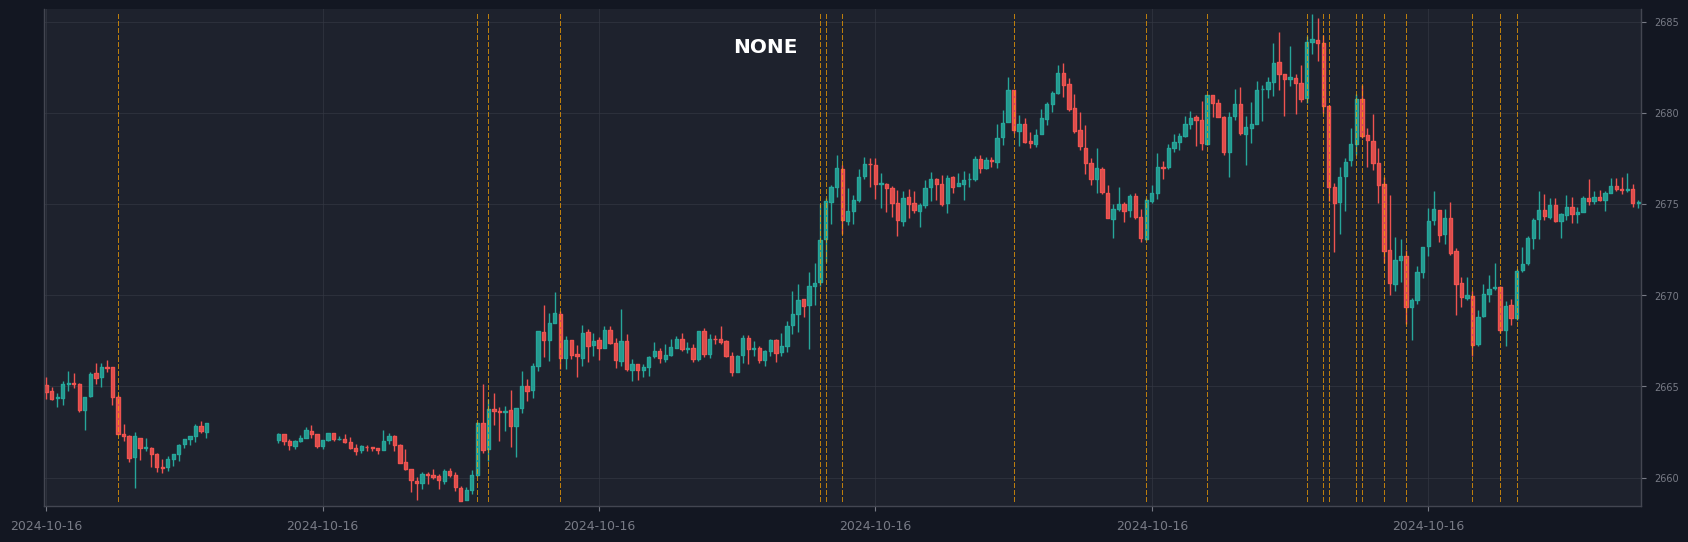

In [41]:
dta = resampler.resample(df,'5min', '2024-10-16', '2024-10-17')

dta['OC'] = ((dta['close'] - dta['open']) * 100 ).abs()

dta['oc_above_400'] = dta['OC'] > 200

mask = dta.index[dta['oc_above_400'] == True]


"""Creating The Main Chart"""

fig, axes =chartter.plot(
    dta,
    config=cnf,
    vlines = {
        'vlines': mask.to_list(),
        'colors': 'orange',
        'linewidths': 0.9,
        'linestyle': '--',
        'alpha': 0.7
    },
    returnfig=True
)

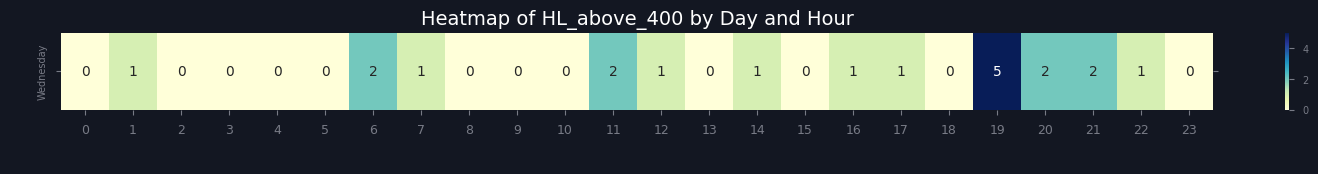

In [42]:
dta['Day'] = dta.index.day_name()
dta['Hour'] = dta.index.hour

import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = dta.pivot_table(
    index='Day',
    columns='Hour',
    values='oc_above_400',
    aggfunc='sum',
    fill_value=0
)

days_order = ['Wednesday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(16,1))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of HL_above_400 by Day and Hour")
plt.show()


In [43]:
import pandas as pd

def extract_hl_windows(df, flag_col='oc_above_400', window=5):
    """
    Extract highlight windows around rows where df[flag_col] is True.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame with a datetime index.
    flag_col : str, default 'oc_above_400'
        Column name containing boolean flags.
    window : int, default 5
        Number of rows before and after each flagged index to include.

    Returns
    -------
    list[pd.DataFrame]
        A list of sub-DataFrames, each centered on a True flag row.
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    hl_windows = []
    true_indices = df.index[df[flag_col]]

    for idx in true_indices:
        pos = df.index.get_loc(idx)
        start = max(0, pos - window)
        end = pos + window + 1
        sub_df = df.iloc[start:end].copy()
        sub_df['highlight'] = (sub_df.index == idx).astype(int)
        hl_windows.append(sub_df)
    return hl_windows


df_march = dta.copy()
hl_windows = extract_hl_windows(df_march, flag_col='oc_above_400', window=5)




In [44]:
import matplotlib.pyplot as plt
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

def plot_lower_tf_windows(hl_windows, df_list, tf_labels, pre_offsets=None, highlight_tf_idx=0, charts_per_row=2):
    """
    Plot lower timeframe windows (e.g., 5-min and 1-min) for all HL windows.
    highlight_tf_idx: index in df_list where vertical line should appear (5-min chart)
    charts_per_row: charts per row (2 by default)
    """
    n_windows = len(hl_windows)
    n_tfs = len(df_list)
    total_charts = n_windows * n_tfs
    rows = int(np.ceil(total_charts / charts_per_row))

    if pre_offsets is None:
        pre_offsets = [pd.Timedelta('0min')] * n_tfs

    fig, axes = plt.subplots(rows, charts_per_row, figsize=(5*charts_per_row, 4*rows))
    axes = axes.flatten()

    for i, window in enumerate(hl_windows):
        hl_start, hl_end = window.index[0], window.index[-1]
        main_candle_idx = window['highlight'].idxmax()  # main HL candle

        for j, (df, label, offset) in enumerate(zip(df_list, tf_labels, pre_offsets)):
            ax_idx = i * n_tfs + j
            if ax_idx >= len(axes):
                continue
            ax = axes[ax_idx]

            start = hl_start - offset
            df_range = df.loc[start:hl_end]

            if df_range.empty:
                ax.axis('off')
                continue

            # OHLC preparation
            ohlc = df_range.assign(date=mdates.date2num(df_range.index))[['date','open','high','low','close']].values
            width = 0.6 * np.mean(np.diff(ohlc[:, 0])) if len(df_range) > 1 else 0.03

            candlestick_ohlc(ax, ohlc, width=width, colorup='g', colordown='r', alpha=0.9)

            # Draw vertical line only on specified TF (e.g., 5-min)
            if j == highlight_tf_idx:
                closest_idx = df_range.index.get_indexer([main_candle_idx], method='nearest')[0]
                closest_time = df_range.index[closest_idx]
                ax.axvline(mdates.date2num(closest_time), color='white', ls='--', lw=2)

            ax.set_title(f"{hl_start} #{i+1} ")
            ax.xaxis_date()
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            ax.grid(True)

    for ax in axes[total_charts:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()



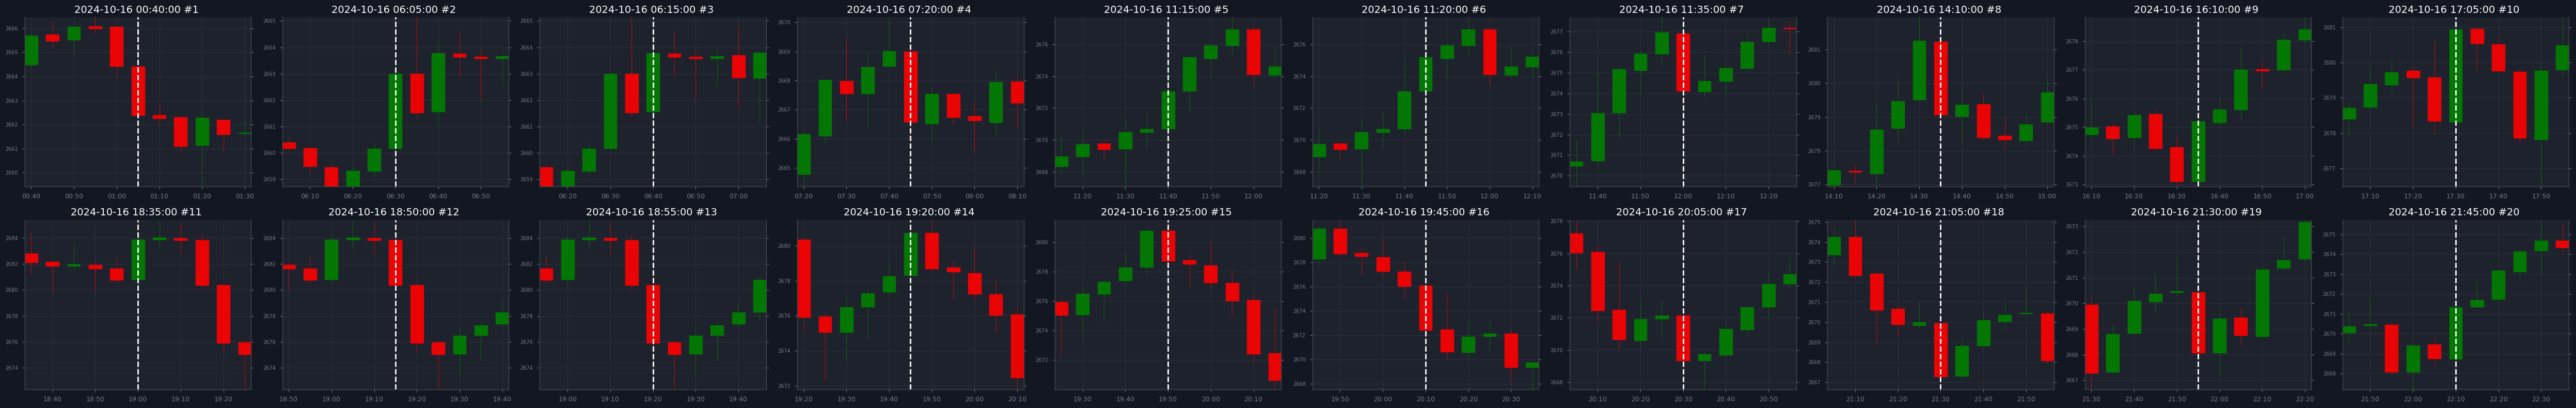

In [45]:
pre_offsets = [pd.Timedelta('0min'), pd.Timedelta('0min')]

plot_lower_tf_windows(hl_windows, [dta] , ['5min'], pre_offsets=pre_offsets, highlight_tf_idx=0, charts_per_row=10)

In [46]:
dtaSet = sourceClean_5M

dtaSet['OC'] = ((dtaSet['close'] - dtaSet['open']) * 100 ).abs()

dtaSet['oc_above_400'] = dtaSet['OC'] > 200

dtaSet['Day'] = dtaSet.index.day_name()

dtaSet['Hour'] = dtaSet.index.hour

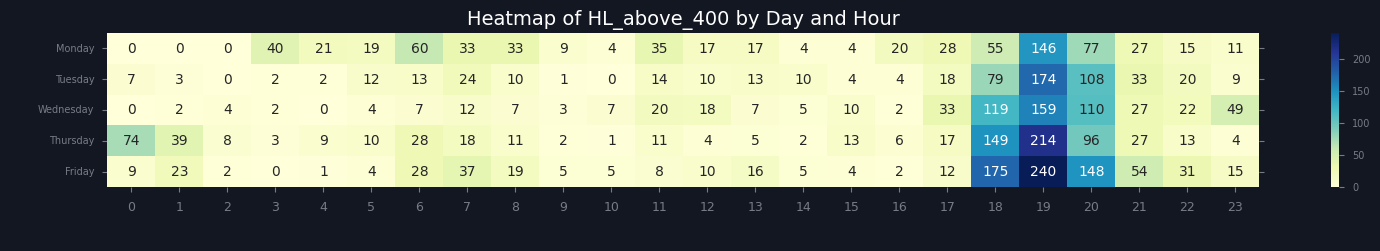

In [47]:

heatmap_data = dtaSet.pivot_table(
    index='Day',
    columns='Hour',
    values='oc_above_400',
    aggfunc='sum',
    fill_value=0
)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(16,2))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap of HL_above_400 by Day and Hour")
plt.show()


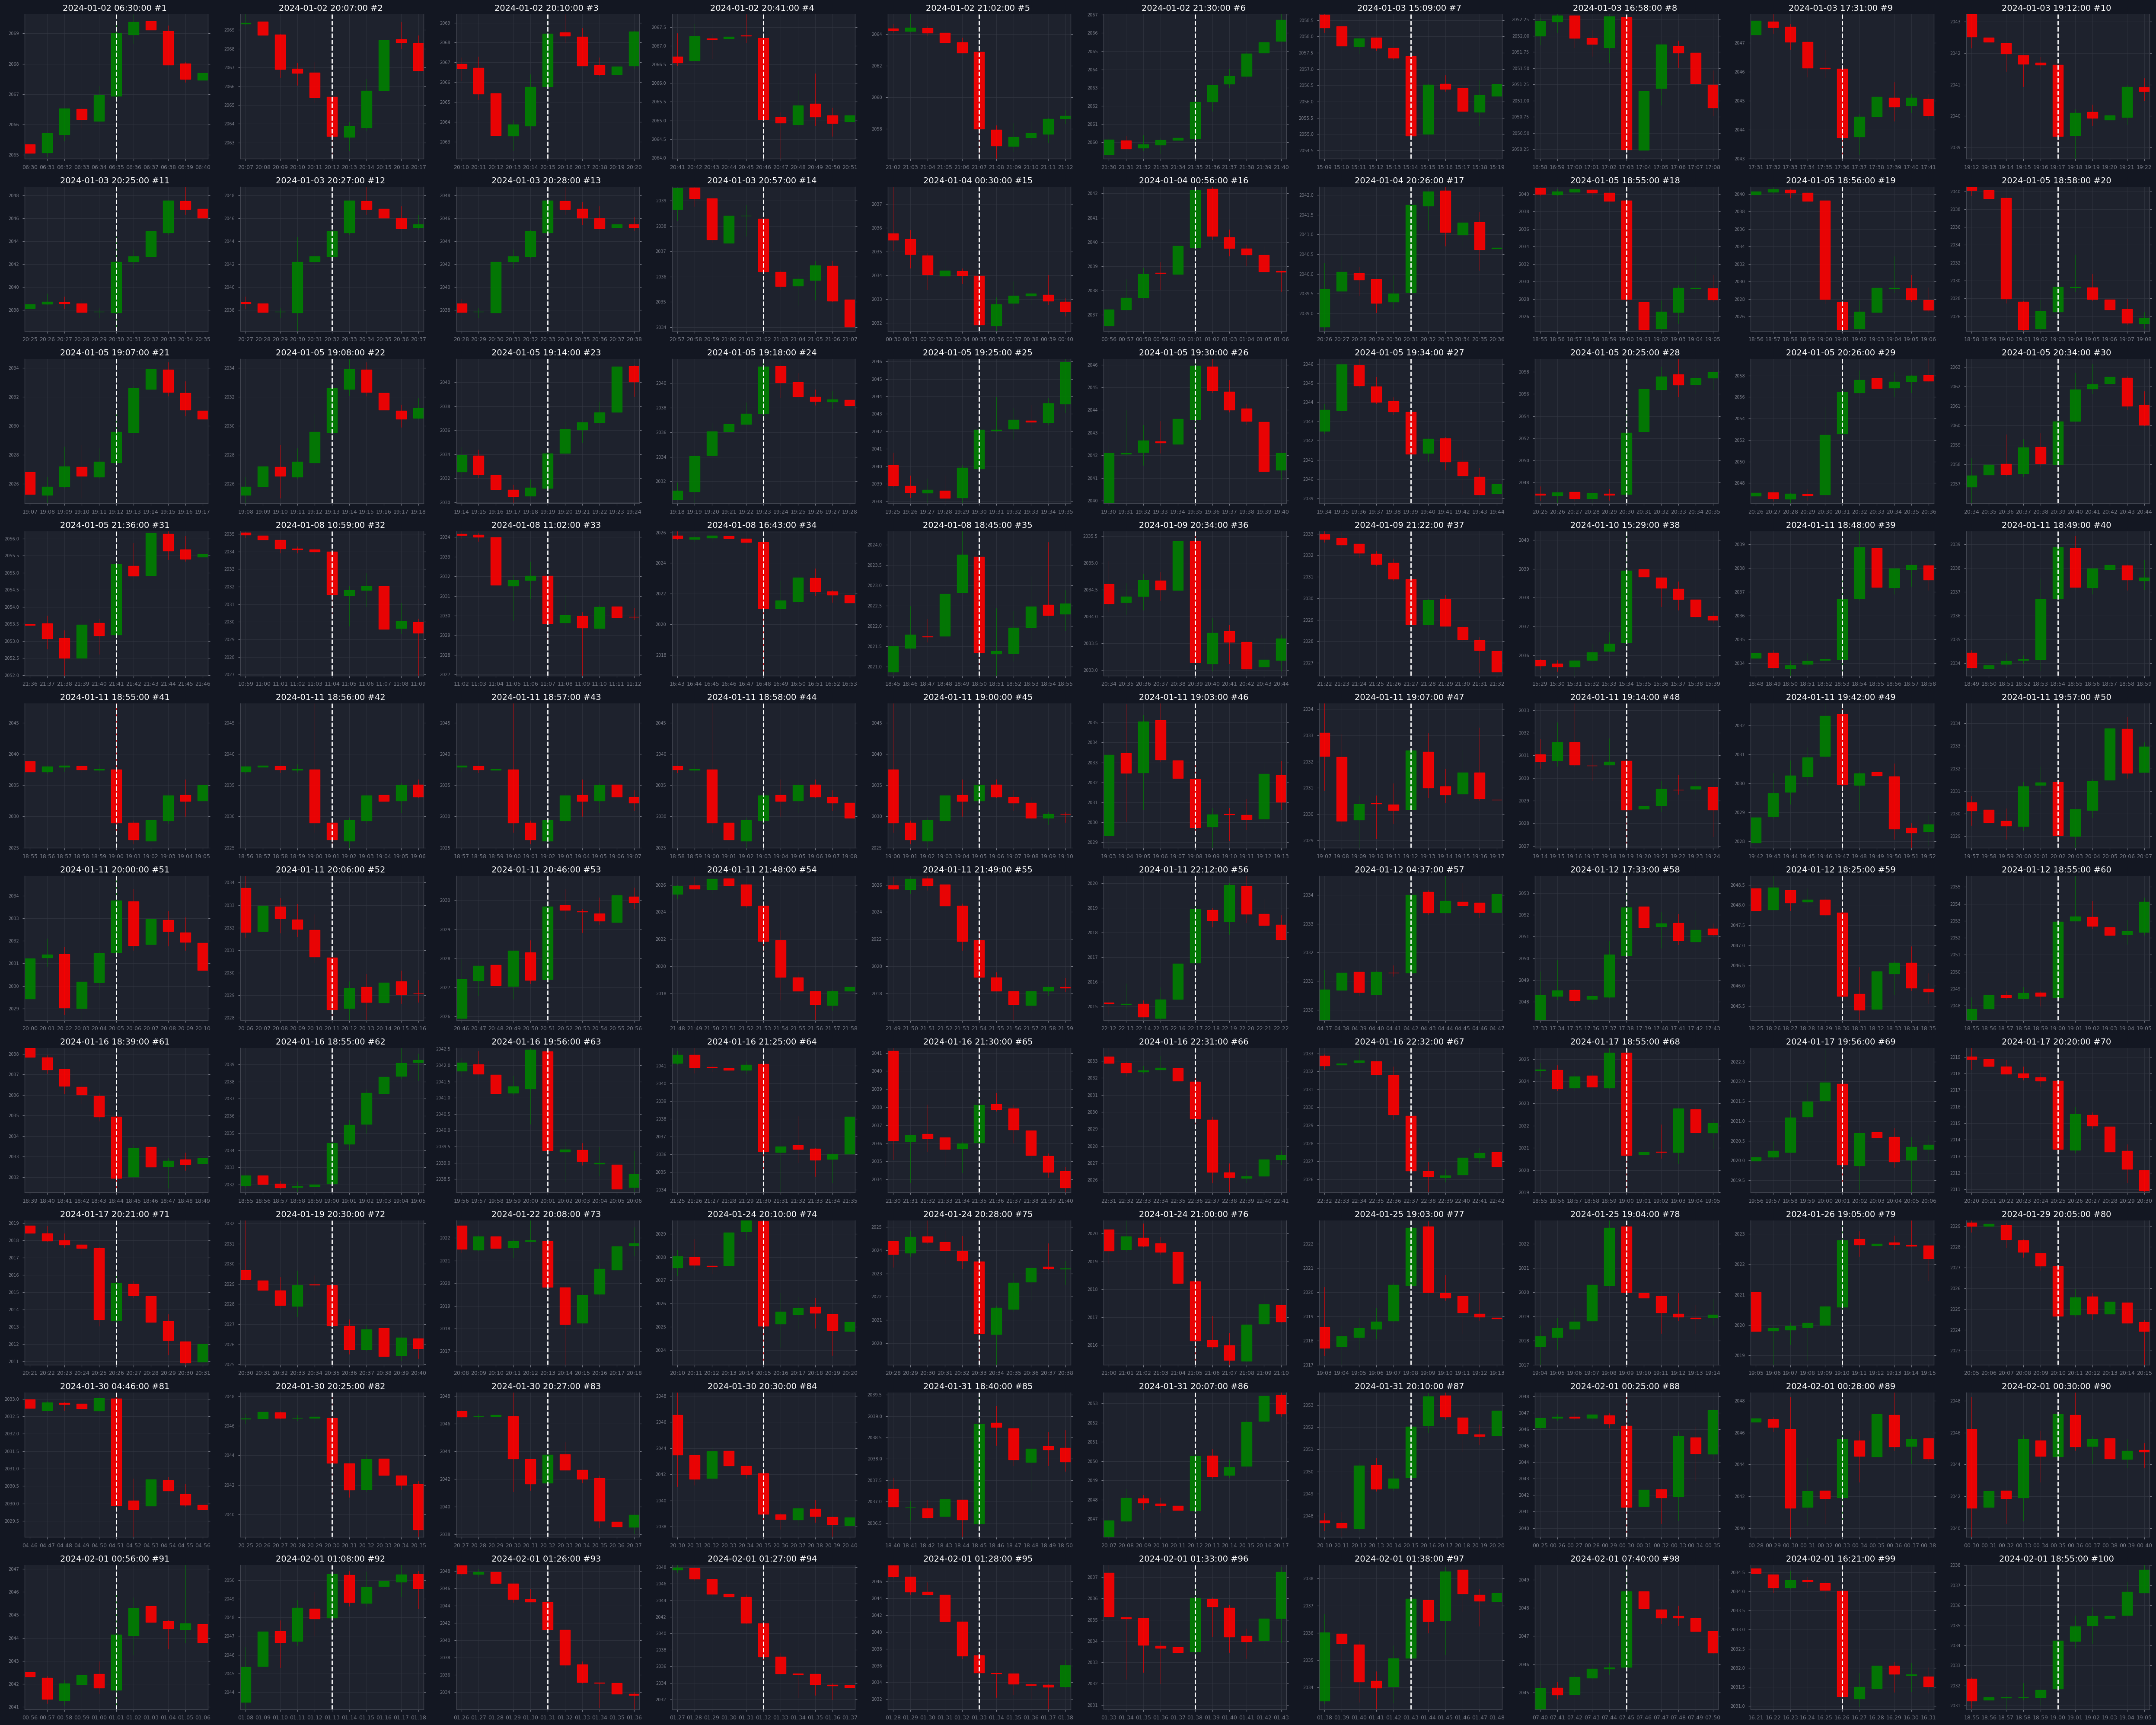

In [48]:
dtaSet_windows = extract_hl_windows(dtaSet, flag_col='oc_above_400', window=5)

plot_lower_tf_windows(dtaSet_windows[:100], [dtaSet] , ['5min'], pre_offsets=pre_offsets, highlight_tf_idx=0, charts_per_row=10)

### `GO deeper`

In [49]:
ohlc_cols = ['open', 'high', 'low', 'close', 'volume']
lorem = sourceClean_5M.copy()

# Forward-fill just those columns
lorem[ohlc_cols] = lorem[ohlc_cols].ffill()


addplot = []

# periods = [21,51,151,251,500]  # 21 to 30, adjust as needed

# for p in periods:
#     lorem[f'EMA_{p}'] = talib.EMA(lorem['close'], timeperiod=p)

# --- MACD ---
lorem['MACD'], lorem['MACD_signal'], lorem['MACD_hist'] = talib.MACD(
    lorem['close'], fastperiod=12, slowperiod=26, signalperiod=9
)

lorem['rsi_14']= ta.rsi(lorem['close'], length=14)

# --- ATR ---
atr_period = 14
lorem['ATR'] = talib.ATR(lorem['high'], lorem['low'], lorem['close'], timeperiod=atr_period)
lorem['ATR_smooth'] = talib.SMA(lorem['ATR'], timeperiod=atr_period)

# --- Bollinger Bands ---
bb_period = 20
bb_std = 2
upper, middle, lower = talib.BBANDS(lorem['close'], timeperiod=bb_period, nbdevup=bb_std, nbdevdn=bb_std)
lorem['BB_upper']   =   upper
lorem['BB_lower']   =   lower
lorem['BB_middle']  =   middle

# lorem.tail()

2025-10-21 12:11:51,873 [INFO] Generating chart 0f44bf63-c734-41e6-a6c3-267917ad8318 with 289 data points


2025-10-21 12:11:52,640 [INFO] Chart 0f44bf63-c734-41e6-a6c3-267917ad8318 generated successfully in 0.78s


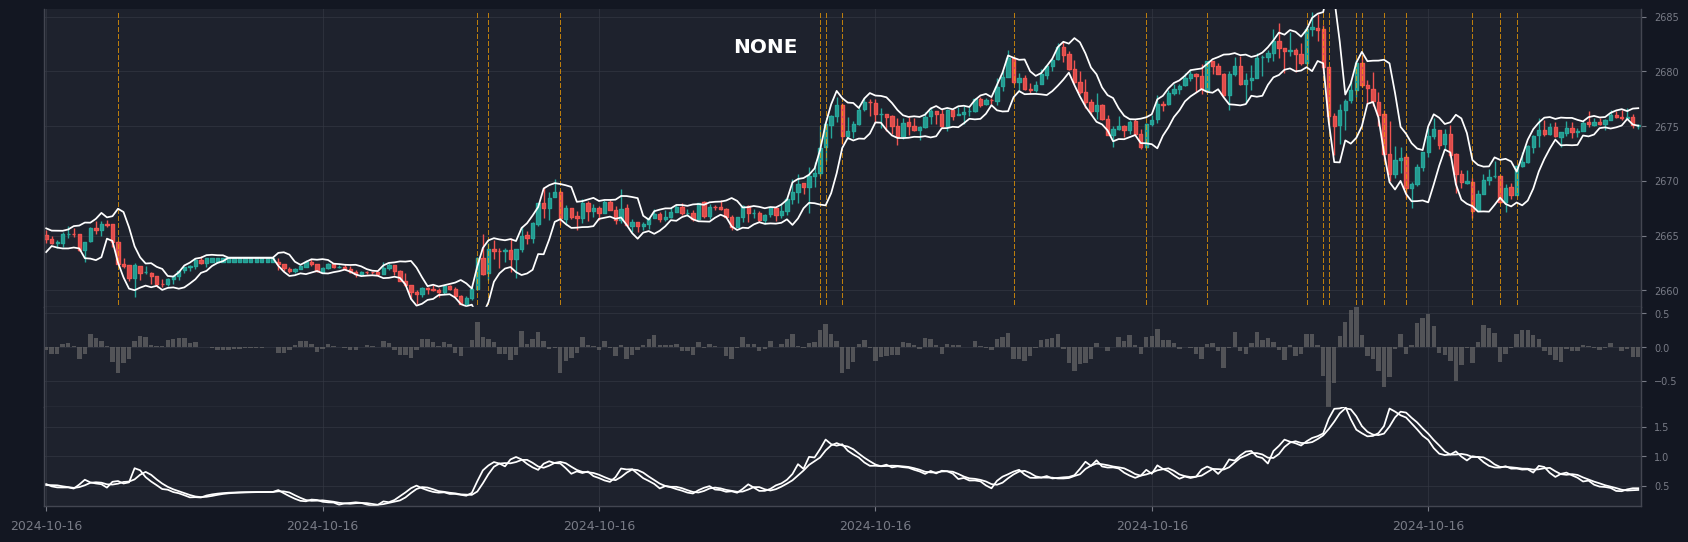

In [50]:
dta = resampler.resample(lorem,'5min', '2024-10-16', '2024-10-17')

# cnf['figratio'] =   (8,3)
cnf['panel_ratios'] =   (5, 2)

"""Creating The Main Chart"""
fig, axes =chartter.plot(
    dta,
    addplot = [
        # mpf.make_addplot(dta['MACD'], panel=1, color='fuchsia', ylabel='MACD'),
        mpf.make_addplot(dta['BB_upper'], panel=0, color='white'),
        mpf.make_addplot(dta['BB_lower'], panel=0, color='white'),
        mpf.make_addplot(dta['ATR'], panel=2, color='white'),
        mpf.make_addplot(dta['ATR_smooth'], panel=2, color='white'),
        mpf.make_addplot(dta['MACD_hist'], panel=1, type='bar', color='dimgray', alpha=0.7),
    ],
    config=cnf,
    vlines = {
        'vlines': mask.to_list(),
        'colors': 'orange',
        'linewidths': 0.9,
        'linestyle': '--',
        'alpha': 0.7
    },
    returnfig=True
)

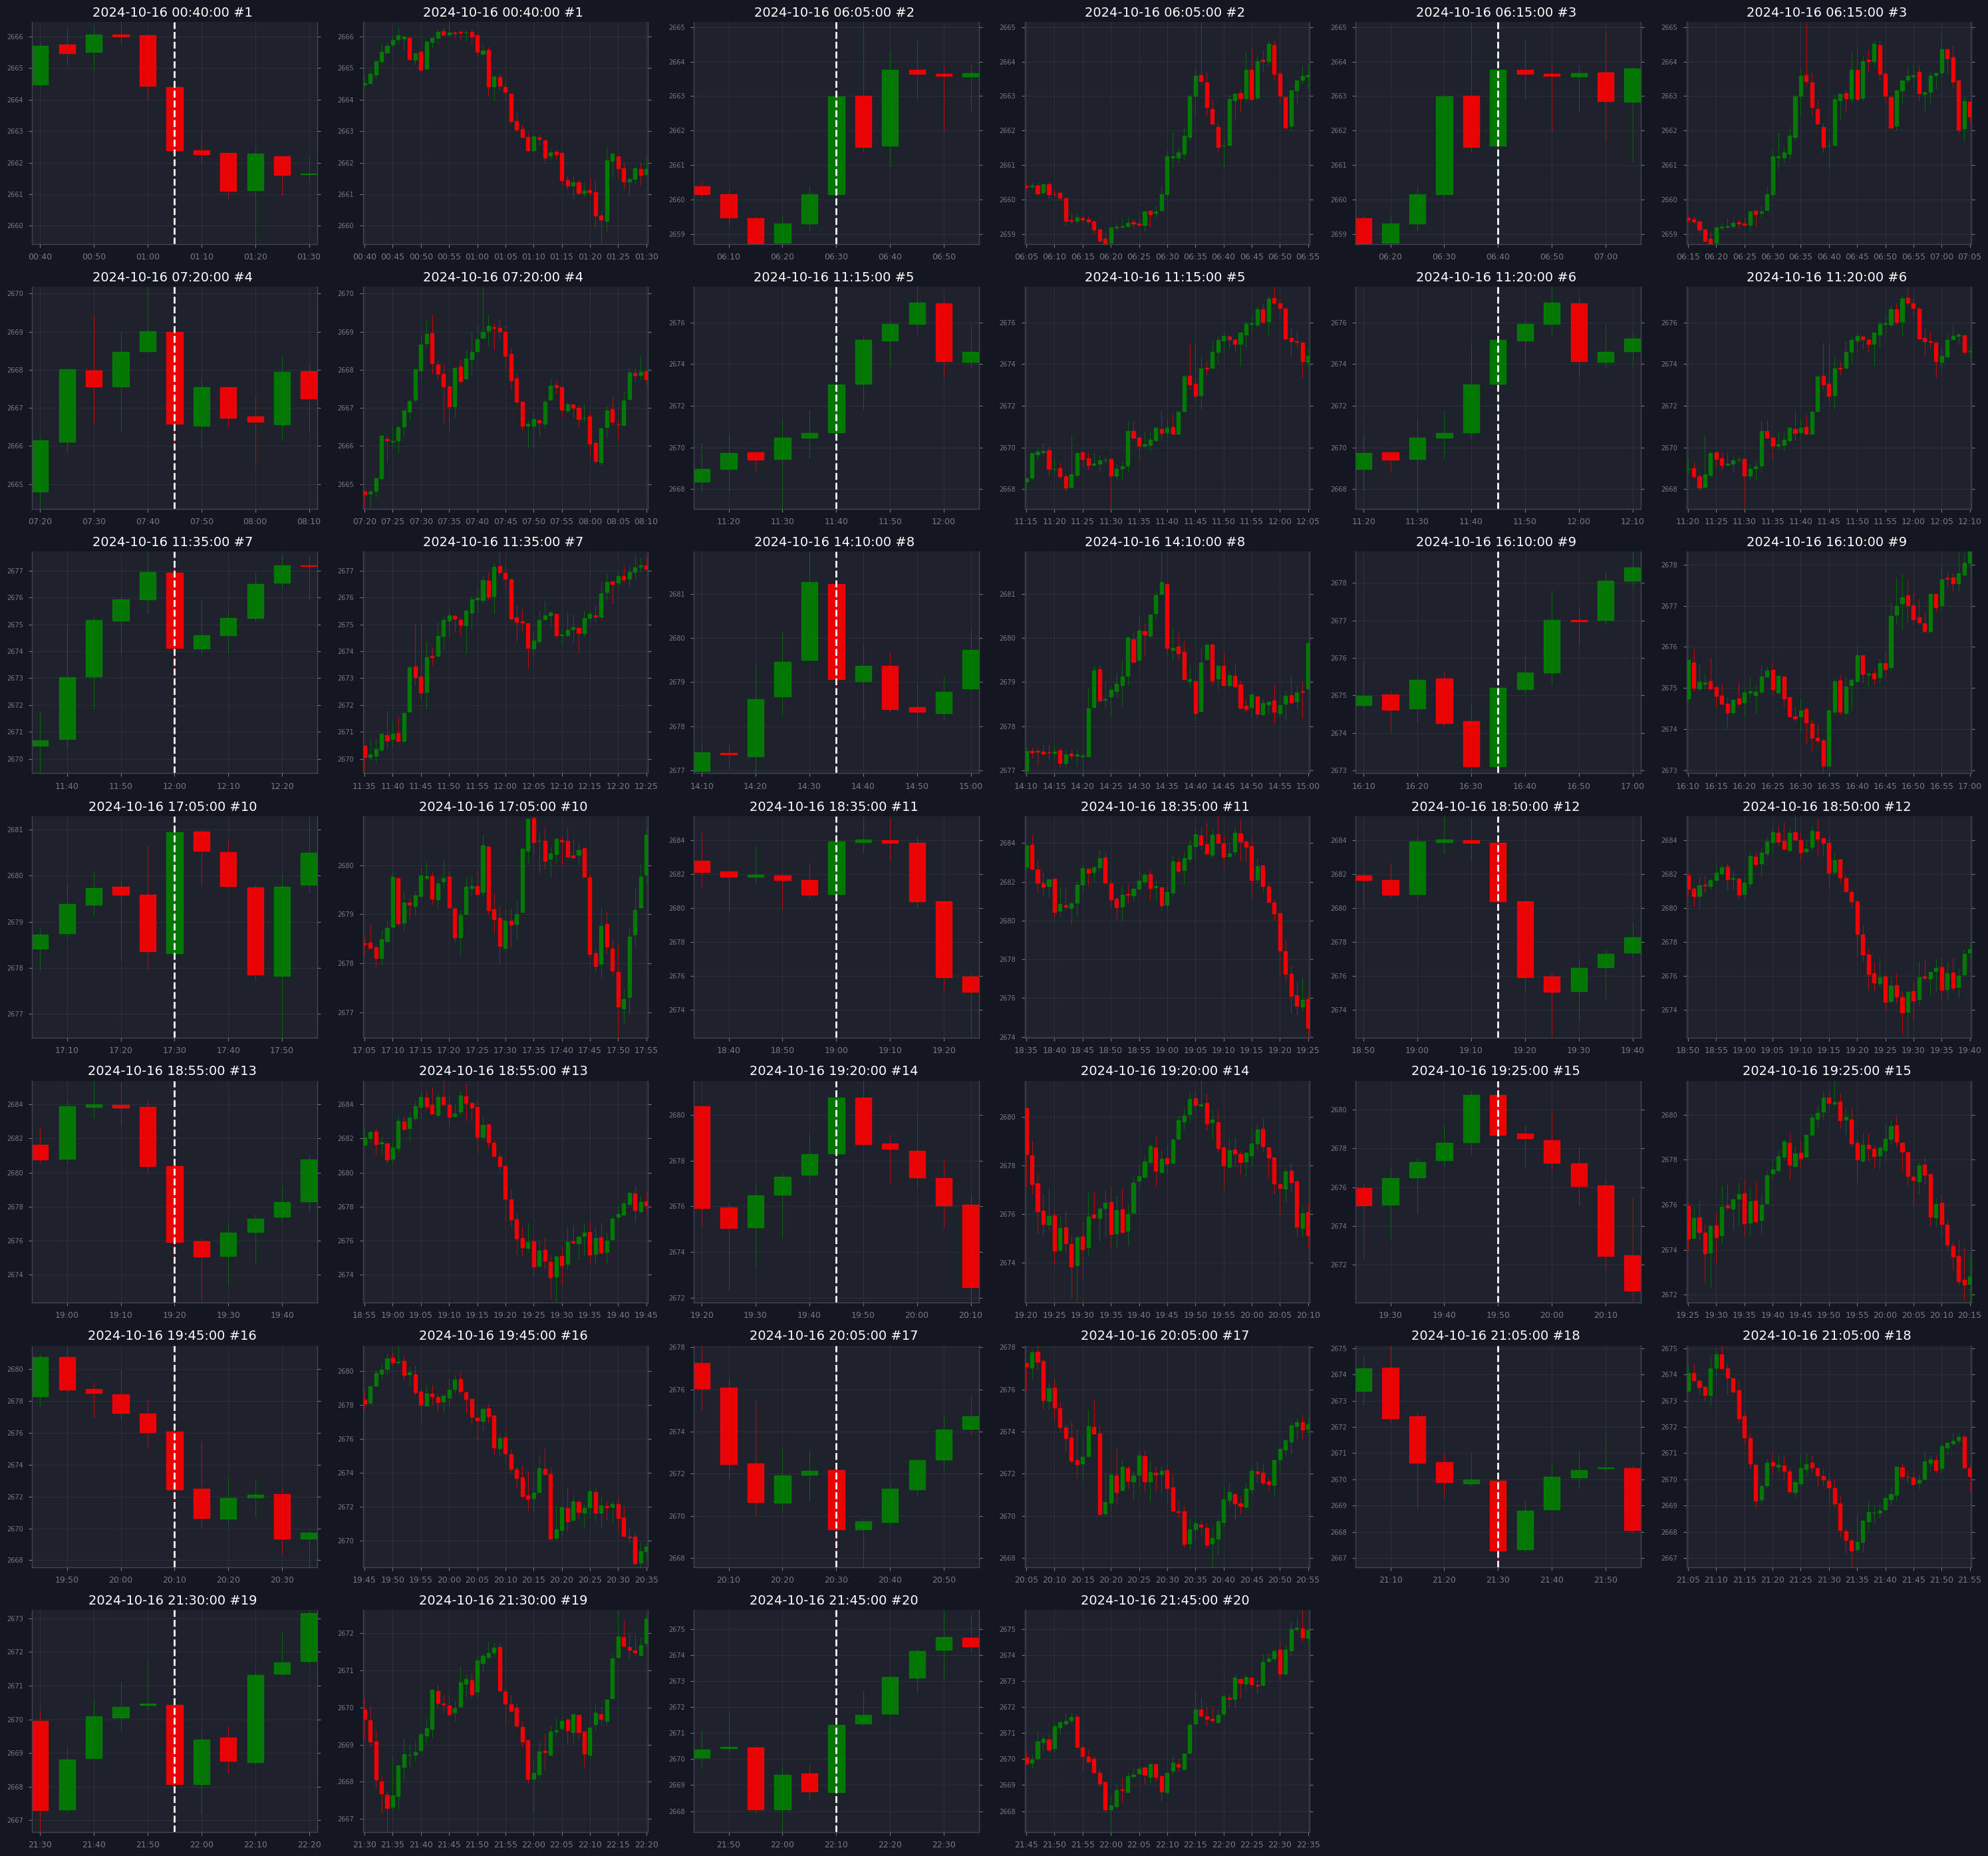

In [51]:
plot_lower_tf_windows(
    hl_windows,
    [dta[ohlc_cols], sourceClean_1M ] ,
    ['5min', '1min'],[pd.Timedelta('0min'), pd.Timedelta('0min')],
    highlight_tf_idx=0, charts_per_row=6
)

In [52]:
from datetime import timedelta

def showNRI(hl_windows = hl_windows[0], lorem=[]):
    start = (hl_windows.index[0]) - timedelta(minutes=5*2)
    end = (hl_windows.index[-1]) + timedelta(minutes=5*2)
    return resampler.resample(lorem,'1min',start, end )

In [53]:
import mplfinance as mpf
from PIL import Image
from io import BytesIO
from IPython.display import display

def render_chart_image(df, addplot=None, figsize=(6,4)):
    """Render an mplfinance chart to a PIL Image"""
    addplot = addplot or []


    # ✅ Use gridcolor and gridstyle only
    custom_style = mpf.make_mpf_style(
        base_mpf_style='nightclouds',
        gridcolor='dimgray',     # or 'gray', '#444444', etc.
        gridstyle='-'
    )

    # ✅ use matplotlib rcParams
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.7   # grid transparency

    fig, _ = mpf.plot(
        df,
        type='candle',
        addplot=addplot,
        style=custom_style,
        returnfig=True,
        figsize=figsize,
        volume=False,
        show_nontrading=False,
        xrotation=0,
    )
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf)
    plt.close(fig)
    return img


def three_chart_canvas(df_1m, df_5m, df_15m, add1min=None,
                       canvas_size=(700, 350), show=True):
    """Return a PIL Image canvas combining 3 sub-charts"""
    add1min = add1min or []

    canvas_width, canvas_height = canvas_size
    split_x = int(canvas_width * 0.6)
    split_y = canvas_height // 2

    # Base blank canvas
    canvas = Image.new("RGB", (canvas_width, canvas_height), "white")

    # Render individual charts
    img_1m  = render_chart_image(df_1m, add1min, figsize=(6,5))
    img_15m = render_chart_image(df_15m, figsize=(4,2.5))
    img_5m  = render_chart_image(df_5m, figsize=(4,2.5))

    # Resize and paste
    img_1m  = img_1m.resize((split_x, canvas_height))
    img_15m = img_15m.resize((canvas_width - split_x, split_y))
    img_5m  = img_5m.resize((canvas_width - split_x, canvas_height - split_y))

    canvas.paste(img_1m, (0, 0))
    canvas.paste(img_15m, (split_x, 0))
    canvas.paste(img_5m, (split_x, split_y))

    if show:
        display(canvas)

    return canvas  # ✅ <— now you can use this in higher-level compositions


In [54]:
from PIL import Image
from IPython.display import display

def combine_canvases(canvases, layout="horizontal", padding=10, bg_color="white", show=True):
    """
    Combine multiple PIL canvases (child images) into one parent canvas.

    Args:
        canvases (list): List of PIL.Image objects.
        layout (str): "horizontal", "vertical", or "grid".
        padding (int): Space between canvases.
        bg_color (str): Background color.
        show (bool): Display inline if True.

    Returns:
        PIL.Image: The combined parent canvas.
    """
    if not canvases:
        raise ValueError("No canvases provided!")

    widths, heights = zip(*(c.size for c in canvases))

    if layout == "horizontal":
        total_width = sum(widths) + padding * (len(canvases) + 1)
        max_height = max(heights)
        parent = Image.new("RGB", (total_width, max_height + 2 * padding), bg_color)

        x = padding
        for c in canvases:
            parent.paste(c, (x, padding))
            x += c.width + padding

    elif layout == "vertical":
        total_height = sum(heights) + padding * (len(canvases) + 1)
        max_width = max(widths)
        parent = Image.new("RGB", (max_width + 2 * padding, total_height), bg_color)

        y = padding
        for c in canvases:
            parent.paste(c, (padding, y))
            y += c.height + padding

    else:
        raise ValueError("Unsupported layout. Use 'horizontal' or 'vertical'.")

    if show:
        display(parent)

    return parent

### `Current`

In [64]:
import pandas as pd
import pandas_ta as ta
import mplfinance as mpf
from datetime import timedelta
import numpy as np

def jambura(df, bb_length=11, bb_mult=1.7, kc_length=21, kc_mult=1.5):
    """
    Squeeze Indicator using pandas_ta - identifies squeeze state only.

    Parameters:
    - df: DataFrame with OHLC data
    - bb_length: Bollinger Bands length (default 20)
    - bb_mult: Bollinger Bands multiplier (default 2.0)
    - kc_length: Keltner Channel length (default 20)
    - kc_mult: Keltner Channel multiplier (default 1.5)

    Returns:
    - DataFrame with squeeze state indicators
    """
    df_out = df.copy()
    close = df_out['close']
    high = df_out['high']
    low = df_out['low']

    # Calculate Bollinger Bands using pandas_ta
    bb = ta.bbands(close, length=bb_length, std=bb_mult)
    upper_bb = bb.iloc[:, 2]  # Upper band
    lower_bb = bb.iloc[:, 0]  # Lower band

    # Calculate Keltner Channel using pandas_ta
    kc = ta.kc(high, low, close, length=kc_length, scalar=kc_mult)
    upper_kc = kc.iloc[:, 2]  # Upper KC
    lower_kc = kc.iloc[:, 0]  # Lower KC

    # Squeeze detection: BB inside KC
    sqz_on = (lower_bb > lower_kc) & (upper_bb < upper_kc)
    no_sqz = (lower_bb < lower_kc) & (upper_bb > upper_kc)
    sqz_off = ~sqz_on & ~no_sqz

    # Signal colors
    signal_colors = np.empty(len(df_out), dtype=object)
    signal_colors[sqz_on] = 'black'
    signal_colors[no_sqz] = 'blue'
    signal_colors[sqz_off] = 'gray'

    df_out['sqz_on'] = sqz_on
    df_out['no_sqz'] = no_sqz
    df_out['sqz_off'] = sqz_off
    df_out['signal_color'] = signal_colors

    return df_out

def jambura_canvas(hl_windows, lorem, include_squeeze=True):
    """
    Generate mplfinance canvases for each highlight window with MACD, ATR, and Squeeze Momentum.

    Parameters:
    - hl_windows: list of highlight windows with datetime index
    - lorem: original OHLC DataFrame
    - include_squeeze: whether to include Squeeze Momentum indicator (default True)
    """
    canvas = []

    # Detect OHLC columns case-insensitively
    col_map = {col.lower(): col for col in lorem.columns}
    required_cols = ['open', 'high', 'low', 'close']
    if not all(c in col_map for c in required_cols):
        raise ValueError(f"Your data must contain OHLC columns: {required_cols}")

    open_col = col_map['open']
    high_col = col_map['high']
    low_col = col_map['low']
    close_col = col_map['close']

    # Add Squeeze Momentum to main data if requested
    if include_squeeze:
        lorem = jambura(lorem)

    for hlw in hl_windows:
        # Extend window by 2 bars of 5-min each
        sx = hlw.index[0] - timedelta(minutes=5*2)
        ex = hlw.index[-1] + timedelta(minutes=5*2)

        # Resample the main data 'lorem' to 1-min in this window
        dtaX = resampler.resample(lorem, '1min', sx, ex)

        # MACD cross signals
        dtaX['cross_up'] = ta.cross(dtaX['MACD'], dtaX['MACD_signal'])
        dtaX['cross_dn'] = ta.cross(dtaX['MACD_signal'], dtaX['MACD'])

        cross_up = dtaX['MACD'].where(dtaX['cross_up'] != 0)
        cross_dn = dtaX['MACD'].where(dtaX['cross_dn'] != 0)

        # Calculate RSI
        rsi = dtaX['rsi_14']

        # Build addplot list
        add_plots = [
            # MACD
            mpf.make_addplot(dtaX['MACD_hist'], panel=2, type='bar', color='dimgray', alpha=0.7),
            mpf.make_addplot(dtaX['MACD_signal'], panel=2, type='line', color='white', alpha=0.7, width=0.8),
            mpf.make_addplot(dtaX['MACD'], panel=2, type='line', color='blue', alpha=0.7, width=0.8),
            mpf.make_addplot(cross_up, panel=2, type='step', color='yellow'),
            mpf.make_addplot(cross_dn, panel=2, type='step', color='red'),
        ]

        # Add Squeeze Level indicator - zero line only with squeeze state colors
        if include_squeeze and 'signal_color' in dtaX.columns:
            squeeze_level = pd.Series(0, index=dtaX.index)
            signal_colors = dtaX['signal_color'].values

            # Plot squeeze line with scatter markers colored by state
            for color in ['black', 'blue', 'gray']:
                mask = signal_colors == color
                if mask.any():
                    signal_pts = squeeze_level.copy()
                    signal_pts[~mask] = np.nan
                    add_plots.append(mpf.make_addplot(signal_pts, panel=1, type='scatter', marker='_',
                                                     color=color, markersize=16, alpha=0.9))

        # Build canvas
        canvas_a = three_chart_canvas(
            dtaX, hlw, hlw,
            add1min=add_plots,
            show=False
        )
        canvas.append(canvas_a)

    return canvas

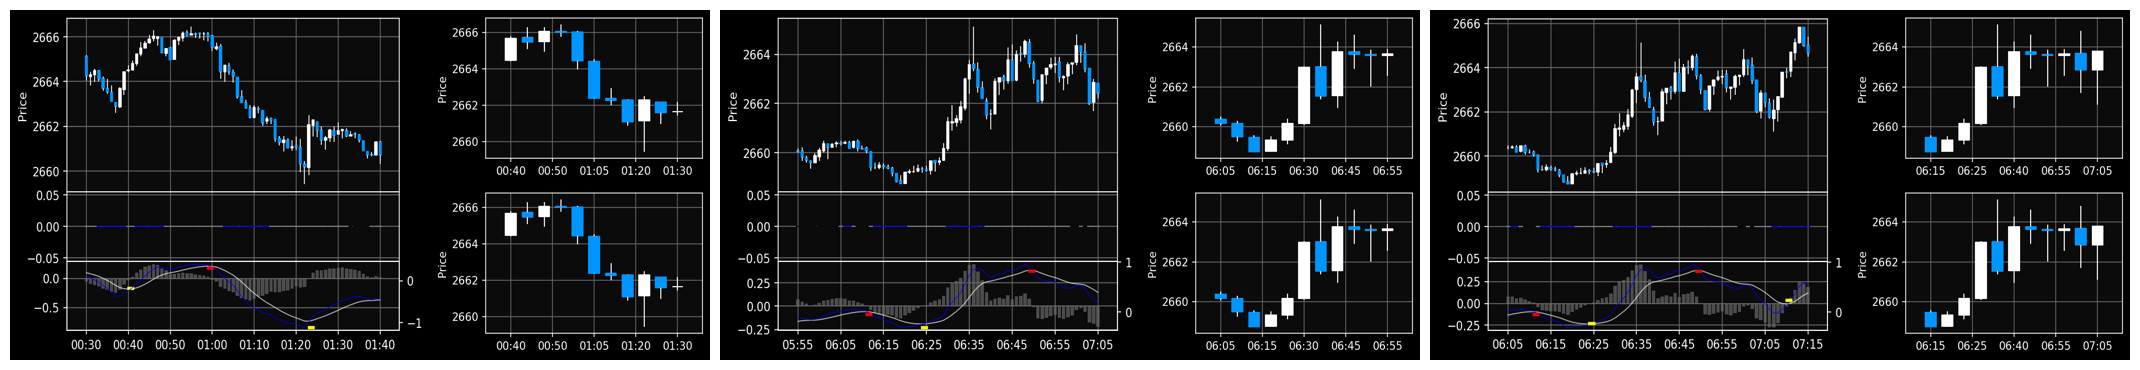

In [65]:
refter  = combine_canvases(jambura_canvas(hl_windows[0:3],lorem), layout="horizontal")
# refter  = combine_canvases(jambura_canvas(hl_windows[3:6],lorem), layout="horizontal")
# refter  = combine_canvases(jambura_canvas(hl_windows[6:9],lorem), layout="horizontal")